Extracted 7 columns from section_A.pdf: [0, 1, 2, 3, 4, 5, 6]
Inserted 15 records from section_A.pdf (Section A)
Extracted 7 columns from section_B.pdf: [0, 1, 2, 3, 4, 5, 6]
Inserted 12 records from section_B.pdf (Section B)
Extracted 5 columns from section_C.pdf: [0, 1, 2, 3, 4]
Inserted 22 records from section_C.pdf (Section C)
Extracted 7 columns from section_D.pdf: [0, 1, 2, 3, 4, 5, 6]
Inserted 18 records from section_D.pdf (Section D)

Class Toppers:
            StudentID          StudentName Section  Grade
68  GHRUA24011060167  ANJALI GOPAL BONDRE       C   8.85

Lowest Performers:
            StudentID           StudentName Section  Grade
57  GHRUA24011060155  ARPIT SANJAY NIKALJE       C    1.3

Average Passing Rate (%):
 Section
A    80.000000
B    50.000000
C     7.954545
D    83.333333
Name: Pass, dtype: float64


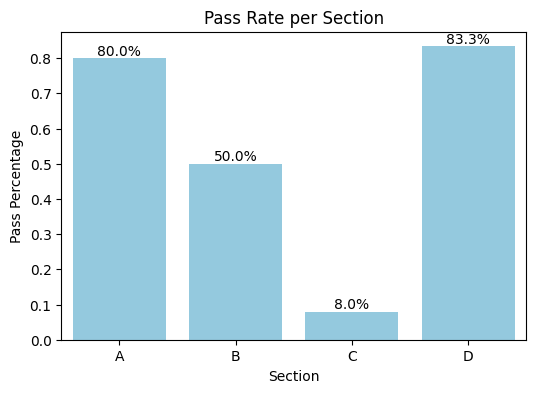

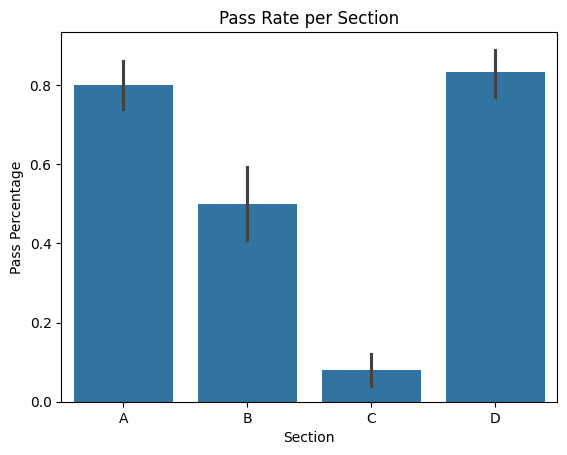

In [16]:
import pandas as pd
import sqlite3
import camelot
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Connect to SQLite database
conn = sqlite3.connect("students.db")

# Step 2: Ensure table schema exists
conn.execute("""
CREATE TABLE IF NOT EXISTS students (
    RNO TEXT,
    StudentID TEXT,
    StudentName TEXT,
    SubjectCode TEXT,
    SubjectName TEXT,
    Grade REAL,
    Result TEXT,
    Section TEXT
)
""")

# Step 3: Function to process a single PDF
def process_pdf(pdf_path, section_name):
    tables = camelot.read_pdf(pdf_path, pages="all")
    if len(tables) == 0:
        print(f"No tables found in {pdf_path}")
        return None
    
    df = tables[0].df
    print(f"Extracted {len(df.columns)} columns from {pdf_path}: {df.columns.tolist()}")  # debug
    
    # --- Normalize schema ---
    if len(df.columns) == 7:
        df.columns = ["RNO","StudentID","StudentName","SubjectCode","SubjectName","Grade","Result"]
        clean_df = df
    elif len(df.columns) == 5:
        df.columns = ["RNO","StudentID","StudentName","SubjectCode","Grade"]
        df["SubjectName"] = None
        df["Result"] = None
        clean_df = df[["RNO","StudentID","StudentName","SubjectCode","SubjectName","Grade","Result"]]
    else:
        print(f"Unexpected column count in {pdf_path}, skipping")
        return None
    
    # Convert Grade to numeric
    clean_df["Grade"] = pd.to_numeric(clean_df["Grade"], errors="coerce")
    
    # Add Section info
    clean_df["Section"] = section_name
    
    # Save to SQL
    clean_df.to_sql("students", conn, if_exists="append", index=False)
    print(f"Inserted {len(clean_df)} records from {pdf_path} (Section {section_name})")
    return clean_df

# Step 4: List your 4 PDFs and sections
pdf_files = ["section_A.pdf","section_B.pdf","section_C.pdf","section_D.pdf"]
sections = ["A","B","C","D"]

# Step 5: Process each PDF
for pdf, sec in zip(pdf_files, sections):
    process_pdf(pdf, sec)

# Step 6: Run analysis
df_all = pd.read_sql("SELECT * FROM students", conn)

# Normalize Result column for consistency
df_all["Result"] = df_all["Result"].fillna("").astype(str).str.upper()

# Create Pass column (1 if PASS, 0 otherwise)
df_all["Pass"] = (df_all["Result"] == "PASS").astype(int)

# Class toppers (skip NaN grades)
if df_all["Grade"].notna().any():
    toppers = df_all.dropna(subset=["Grade"]).loc[
        df_all.dropna(subset=["Grade"]).groupby("Section")["Grade"].idxmax()
    ]
    print("\nClass Toppers:\n", toppers[["StudentID","StudentName","Section","Grade"]])

    # Lowest performers
    lowest = df_all.dropna(subset=["Grade"]).loc[
        df_all.dropna(subset=["Grade"]).groupby("Section")["Grade"].idxmin()
    ]
    print("\nLowest Performers:\n", lowest[["StudentID","StudentName","Section","Grade"]])
else:
    print("\nNo numeric grades available except Section C.")

# Average pass rate (all sections now included)
avg_pass_rate = df_all.groupby("Section")["Pass"].mean() * 100
print("\nAverage Passing Rate (%):\n", avg_pass_rate)

# --- Pass Rate Bar Chart ---
plt.figure(figsize=(6,4))
ax = sns.barplot(x="Section", y="Pass", data=df_all, errorbar=None, color="skyblue")

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')

plt.title("Pass Rate per Section")
plt.ylabel("Pass Percentage")
plt.show()

# --- Boxplot of grade distribution (will show only sections with numeric grades) ---
sns.barplot(x="Section", y="Pass", data=df_all)
plt.title("Pass Rate per Section")
plt.ylabel("Pass Percentage")
plt.show()

